In [1]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('Bank_Customer_Details.csv')

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df = df.drop(columns=['RowNumber', 'CustomerId','Surname'])

In [5]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
x = df.iloc[:, 0:-1].values
y = df.iloc[:, -1].values

In [7]:
print(x) 

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [8]:
print(y)

[1 0 1 ... 1 1 0]


In [9]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)
ds = df.drop(columns = ["Exited"])

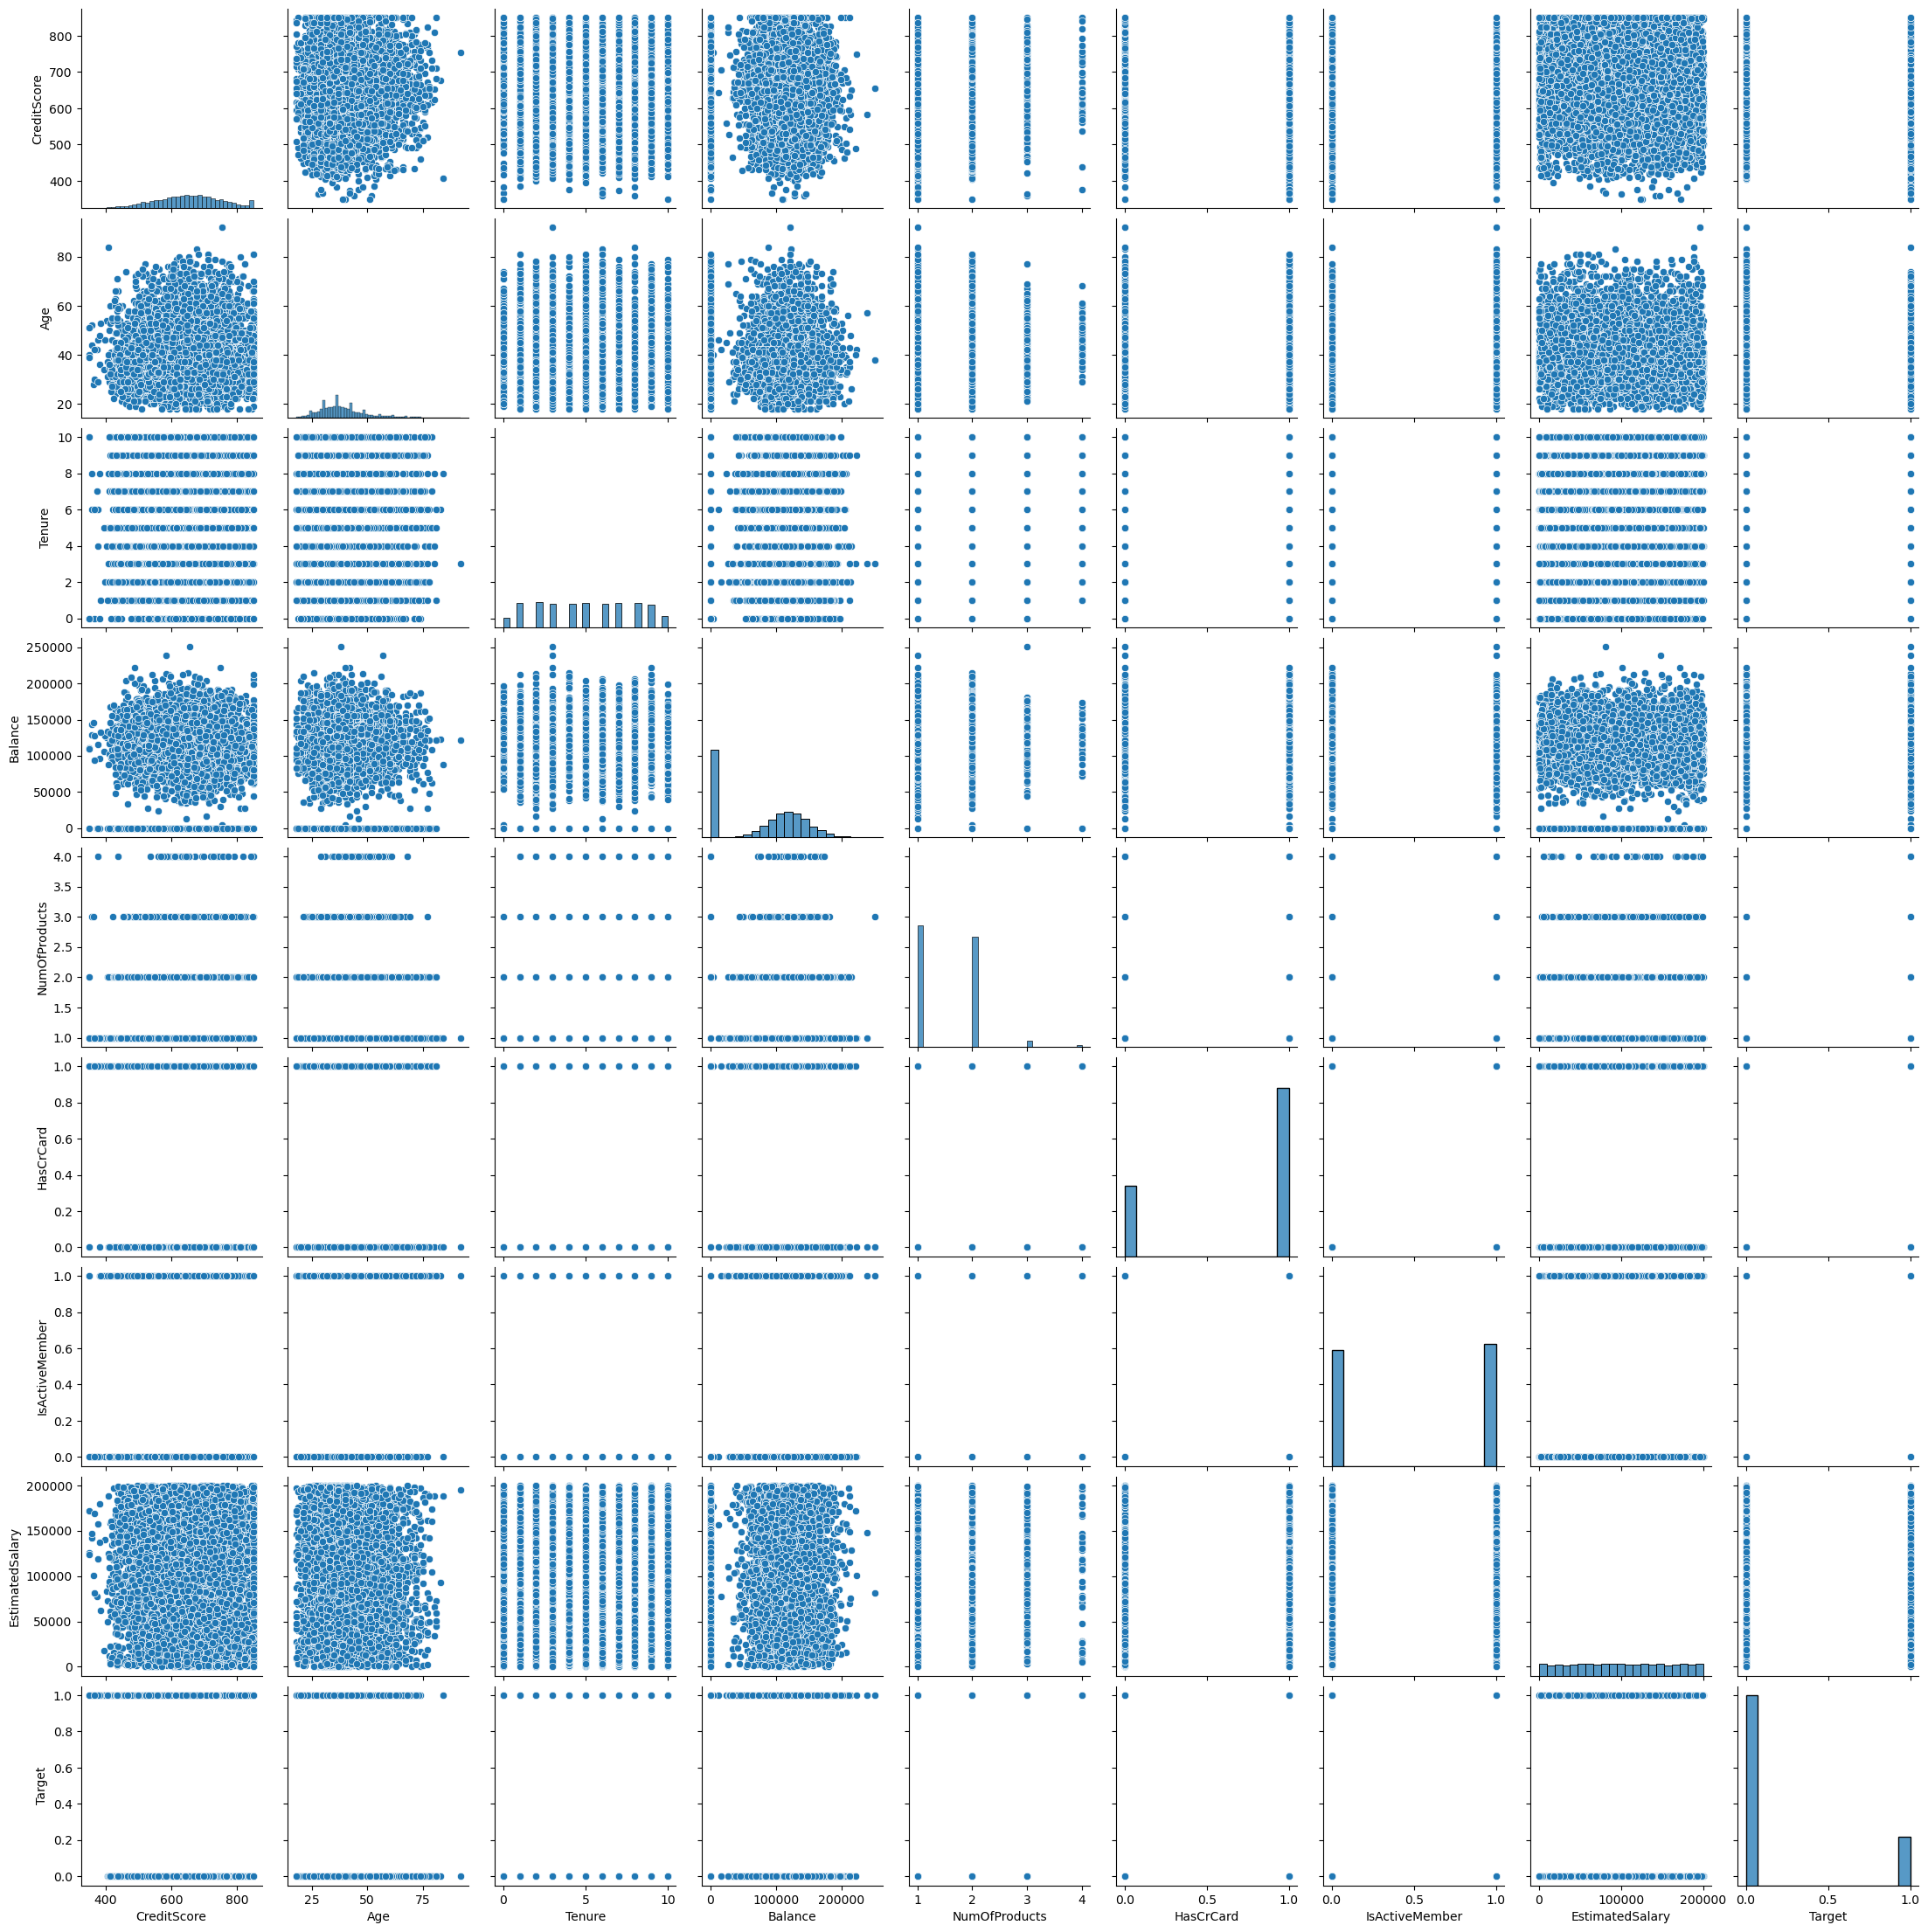

In [10]:
import seaborn as sns
df = pd.DataFrame(x_train, columns=[f'{col}' for col in ds.columns])
df['Target'] = y_train 
sns.pairplot(df)
plt.show()

In [11]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
x_train = ct.fit_transform(x_train)
x_test = ct.fit_transform(x_test)

In [12]:
print(x)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [13]:
le = LabelEncoder()
x_train[:, 4] = le.fit_transform(x_train[:, 4])
x_test[:, 4] = le.fit_transform(x_test[:, 4])

In [14]:
print(x_train)

[[1.0 0.0 0.0 ... 1 1 179093.26]
 [0.0 1.0 0.0 ... 1 1 195978.86]
 [0.0 0.0 1.0 ... 1 0 85891.02]
 ...
 [1.0 0.0 0.0 ... 0 0 92220.12]
 [1.0 0.0 0.0 ... 1 0 97508.04]
 [0.0 1.0 0.0 ... 1 1 53581.14]]


In [15]:
sc1 = StandardScaler()
sc2 = StandardScaler()
x_train[:, 4:] = sc1.fit_transform(x_train[:, 4:])
x_test[:, 4:] = sc2.fit_transform(x_test[:, 4:])

In [16]:
print(x_train[:, 3])

[686 632 559 ... 735 667 697]


In [17]:
x_train[:, 3] = sc1.fit_transform(x_train[:, 3].reshape(-1, 1)).flatten()
x_test[:, 3] = sc2.fit_transform(x_test[:, 3].reshape(-1, 1)).flatten()

In [18]:
print(x_train[:, 3])

[0.3564997084691052 -0.20389776790135397 -0.9614721341058636 ...
 0.8650085296200775 0.1593228186350548 0.4706547499519766]


In [19]:
y_train = y_train.reshape(1, -1)
y_test = y_test.reshape(1, -1)
numIterations = []
costOfItr = []

In [20]:
def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(1)
    W1 = np.random.randn(n_h, n_x) * 0.01  # (n_h, n_x) weight matrix
    b1 = np.zeros((n_h, 1))  # (n_h, 1) bias vector
    W2 = np.random.randn(n_y, n_h) * 0.01  # (n_y, n_h) weight matrix
    b2 = np.zeros((n_y, 1))  # (n_y, 1) bias vector
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters

# ReLU activation function
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0  

# Sigmoid activation function
def sigmoid(Z):
    Z = np.array(Z, dtype=np.float64) 
    return 1 / (1 + np.exp(-Z))

# Forward propagation
def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    # layer 1(hidden layer)
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)  

    # layer 2 (output layer)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)  
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    
    return A2, cache

# Cost function (cross-entropy loss)
def compute_cost(A2, Y):
    m = Y.shape[1]  
    cost = -1/m * np.sum(Y * np.log(A2) + (1 - Y) * np.log(1 - A2))
    return np.squeeze(cost)

# Backward propagation
def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1] 
    W2 = parameters["W2"]
    
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    # Gradients caluclation
    dZ2 = A2 - Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = np.dot(W2.T, dZ2) * relu_derivative(cache["Z1"])  # Derivative of ReLU
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    
    return grads

# Update parameters
def update_parameters(parameters, grads, learning_rate=0.01):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    W1 = W1 - learning_rate * grads["dW1"]
    b1 = b1 - learning_rate * grads["db1"]
    W2 = W2 - learning_rate * grads["dW2"]
    b2 = b2 - learning_rate * grads["db2"]
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    
    return parameters

# Model training
def model(X, Y, n_h, num_iterations=10000, learning_rate=0.01):
    np.random.seed(3)
    n_x = X.shape[0] 
    n_y = Y.shape[0]  
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    for i in range(num_iterations):
        # Forward propagation
        A2, cache = forward_propagation(X, parameters)
        
        # Compute cost
        cost = compute_cost(A2, Y)
        
        # Backward propagation
        grads = backward_propagation(parameters, cache, X, Y)
        
        # Update parameters
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if i % 1000 == 0:
            print(f"Iteration {i}, cost: {cost}")
            numIterations.append(i)
            costOfItr.append(cost)
    
    return parameters

# Prediction
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    predictions = (A2 > 0.5).astype(int)
    return predictions

parameters = model(x_train.T, y_train, n_h=10, num_iterations=10000, learning_rate=0.01)


train_predictions = predict(parameters, x_train.T)
test_predictions = predict(parameters, x_test.T)

# Calculate accuracy
train_accuracy = 100 - np.mean(np.abs(train_predictions - y_train)) * 100
test_accuracy = 100 - np.mean(np.abs(test_predictions - y_test)) * 100

print(f"Training accuracy: {train_accuracy}%")
print(f"Test accuracy: {test_accuracy}%")

Iteration 0, cost: 0.693267355736334
Iteration 1000, cost: 0.5101778292839446
Iteration 2000, cost: 0.5000408110568151
Iteration 3000, cost: 0.47704093301547884
Iteration 4000, cost: 0.44433620823848413
Iteration 5000, cost: 0.4270491445504303
Iteration 6000, cost: 0.4182682081649639
Iteration 7000, cost: 0.4097331954244621
Iteration 8000, cost: 0.4010899338060771
Iteration 9000, cost: 0.391872606261526
Training accuracy: 84.175%
Test accuracy: 84.5%


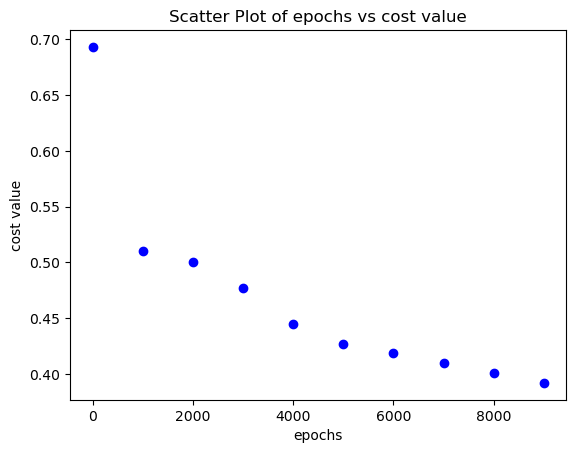

In [21]:
plt.scatter(numIterations, costOfItr, color='blue', label='Epochs vs Cost')
plt.xlabel('epochs')
plt.ylabel('cost value')
plt.title('Scatter Plot of epochs vs cost value')
plt.show()